# PHIL-TEXT — Keşifsel Veri Analizi (EDA)

**Proje:** Felsefe Metinleri Analiz ve Üretim Sistemi  
**Veri:** 10 Filozoftan 24 eser (Project Gutenberg)  
**Amaç:** Modelleme öncesinde veri setinin derinlemesine incelenmesi

---
### İçindekiler
1. Ortam Kurulumu & Veri Yükleme
2. Genel Bakış (Shape, Sütunlar, Eksik Değerler)
3. Corpus Dağılımı (Filozoflar, Dönemler, Akımlar)
4. Metin Uzunluğu Analizi
5. Kelime Hazinesi & Sözcük Analizi
6. Leksikal Çeşitlilik (Type-Token Ratio)
7. Cümle & Kelime Uzunluğu Analizi
8. N-gram Analizi (Bigram / Trigram)
9. Kelime Bulutu Görselleştirmeleri
10. Chunk Analizi
11. Modelleme Öncesi Değerlendirme & Özet

## 1. Ortam Kurulumu & Veri Yükleme

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from src.data.load_data import load_corpus, chunk_texts, get_data_summary

# ── Stil ayarları ──────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

PHIL_COLORS = {
    'platon':          '#4C72B0',
    'aristoteles':     '#DD8452',
    'marcus_aurelius': '#55A868',
    'descartes':       '#C44E52',
    'spinoza':         '#8172B2',
    'locke':           '#937860',
    'hume':            '#DA8BC3',
    'kant':            '#8C8C8C',
    'schopenhauer':    '#CCB974',
    'nietzsche':       '#64B5CD',
}

print('✓ Tüm kütüphaneler yüklendi.')

✓ Tüm kütüphaneler yüklendi.


In [2]:
# Ham corpus yükle
df = load_corpus('../data/raw')
print(f'Corpus boyutu: {df.shape[0]} eser × {df.shape[1]} sütun')
df.head()

2026-02-25 15:08:34.737 | INFO     | src.data.load_data:load_corpus:89 - Corpus uploaded: 24 works, 10 philosophers


Corpus boyutu: 24 eser × 8 sütun


,philosopher,work,text,era,school,char_count,word_count,source_file
0,aristoteles,metaphysics,Produced by Eric Eldred\n\n\n\n\n\n\n\n\n\n\n\...,ancient_greek,realism,108690,18965,..\data\raw\aristoteles\metaphysics.txt
1,aristoteles,nicomachean_ethics,The Nicomachean Ethics of Aristotle\n\n\n\nBy ...,ancient_greek,realism,648681,113322,..\data\raw\aristoteles\nicomachean_ethics.txt
2,aristoteles,poetics,Produced by An Anonymous Volunteer\n\n\n\n\n\n...,ancient_greek,realism,88637,15188,..\data\raw\aristoteles\poetics.txt
3,aristoteles,politics,Produced by Eric Eldred\n\n\n\n\n\n\n\n\n\n\n\...,ancient_greek,realism,584511,102339,..\data\raw\aristoteles\politics.txt
4,descartes,discourse_on_method,DISCOURSE ON THE METHOD \n\nOF RIGHTLY CONDUCT...,modern,rationalism,130464,23039,..\data\raw\descartes\discourse_on_method.txt


## 2. Genel Bakış

In [3]:
print('=== Veri Çerçevesi Bilgisi ===')
df.info()
print()
print('=== Eksik Değerler ===')
print(df.isnull().sum())
print()
print('=== Sayısal Özet ===')
df[['char_count','word_count']].describe().round(0)

=== Veri Çerçevesi Bilgisi ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   philosopher  24 non-null     object
 1   work         24 non-null     object
 2   text         24 non-null     object
 3   era          24 non-null     object
 4   school       24 non-null     object
 5   char_count   24 non-null     int64 
 6   word_count   24 non-null     int64 
 7   source_file  24 non-null     object
dtypes: int64(2), object(6)
memory usage: 1.6+ KB

=== Eksik Değerler ===
philosopher    0
work           0
text           0
era            0
school         0
char_count     0
word_count     0
source_file    0
dtype: int64

=== Sayısal Özet ===


,char_count,word_count
count,24.0,24.0
mean,483016.0,82536.0
std,406360.0,68675.0
min,37213.0,6089.0
25%,167486.0,28864.0
50%,365506.0,60243.0
75%,649736.0,111506.0
max,1345701.0,225756.0


In [4]:
summary = get_data_summary(df)
print(f"Toplam Eser         : {summary['total_records']}")
print(f"Toplam Kelime       : {summary['total_words']:,}")
print(f"Ort. Metin Uzunluğu : {summary['avg_text_length']:,.0f} karakter")
print(f"Dönemler            : {list(summary['eras'].keys())}")
print(f"Akımlar             : {list(summary['schools'].keys())}")

Toplam Eser         : 24
Toplam Kelime       : 1,980,873
Ort. Metin Uzunluğu : 483,016 karakter
Dönemler            : ['modern', 'ancient_greek', 'Contemporary']
Akımlar             : ['idealism', 'realism', 'empiricism', 'rationalism', 'transandantal_idealism', 'existentialism', 'stoicism', 'pessimism']


## 3. Corpus Dağılımı

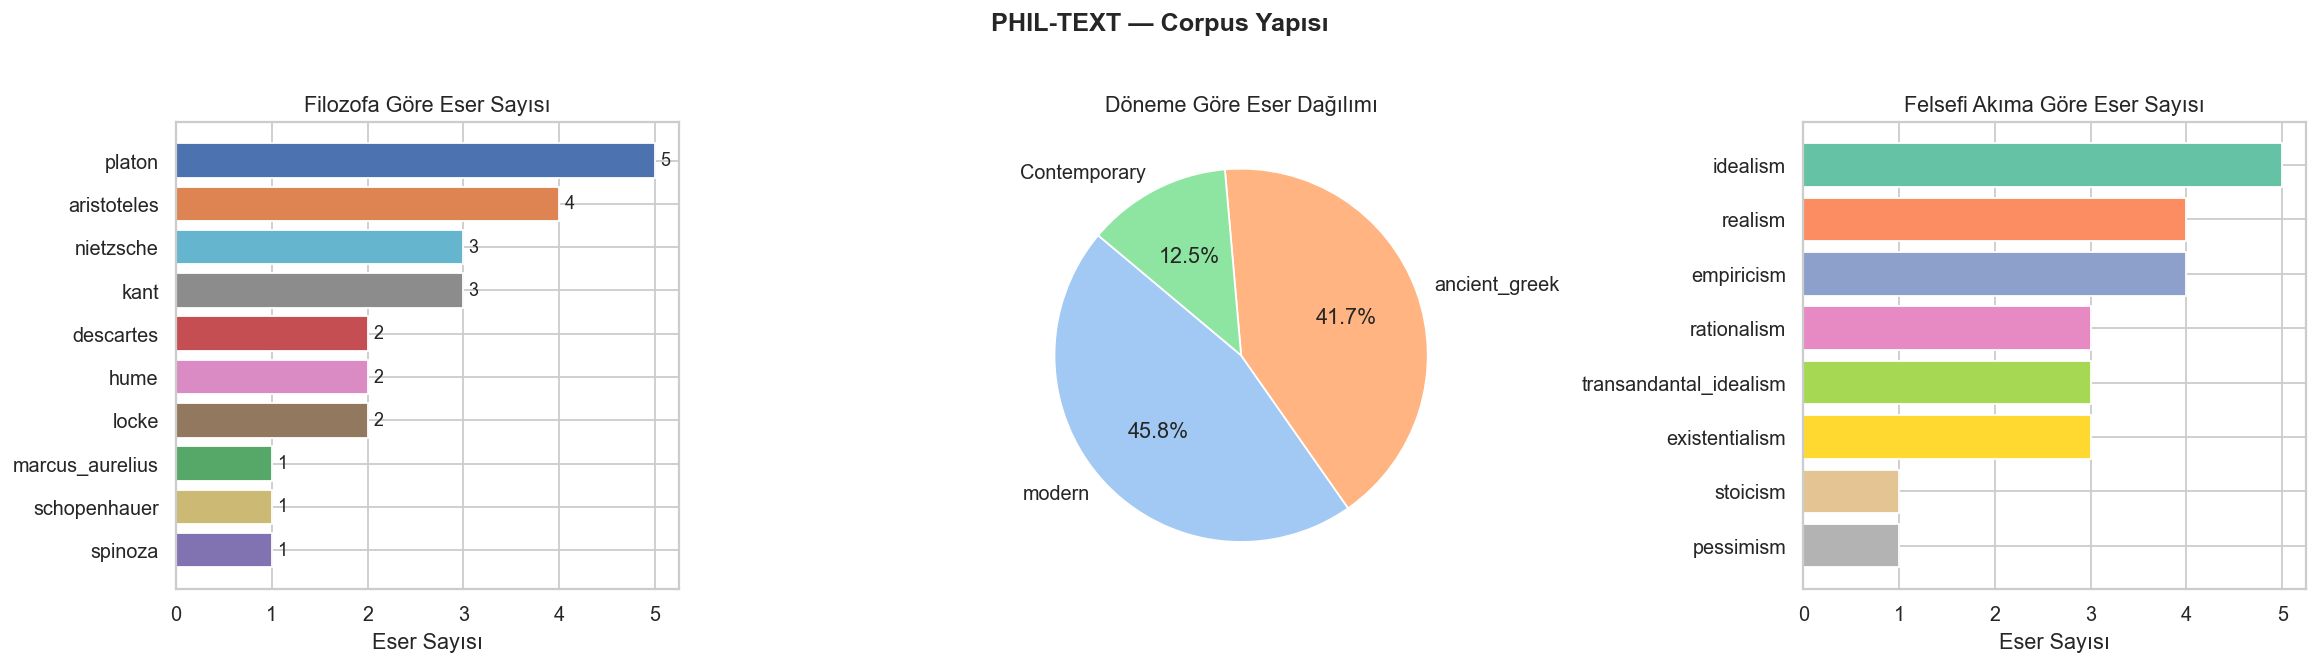

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a — Filozofa göre eser sayısı
ax = axes[0]
work_counts = df['philosopher'].value_counts()
bars = ax.barh(work_counts.index, work_counts.values,
               color=[PHIL_COLORS.get(p, '#888') for p in work_counts.index])
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel('Eser Sayısı')
ax.set_title('Filozofa Göre Eser Sayısı')
ax.invert_yaxis()

# 3b — Döneme göre eser sayısı
ax = axes[1]
era_counts = df['era'].value_counts()
wedges, texts, autotexts = ax.pie(
    era_counts.values, labels=era_counts.index, autopct='%1.1f%%',
    startangle=140, colors=sns.color_palette('pastel', len(era_counts)))
ax.set_title('Döneme Göre Eser Dağılımı')

# 3c — Akıma göre eser sayısı
ax = axes[2]
school_counts = df['school'].value_counts()
ax.barh(school_counts.index, school_counts.values,
        color=sns.color_palette('Set2', len(school_counts)))
ax.set_xlabel('Eser Sayısı')
ax.set_title('Felsefi Akıma Göre Eser Sayısı')
ax.invert_yaxis()

plt.suptitle('PHIL-TEXT — Corpus Yapısı', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/eda_corpus_distribution.png', bbox_inches='tight')
plt.show()

## 4. Metin Uzunluğu Analizi

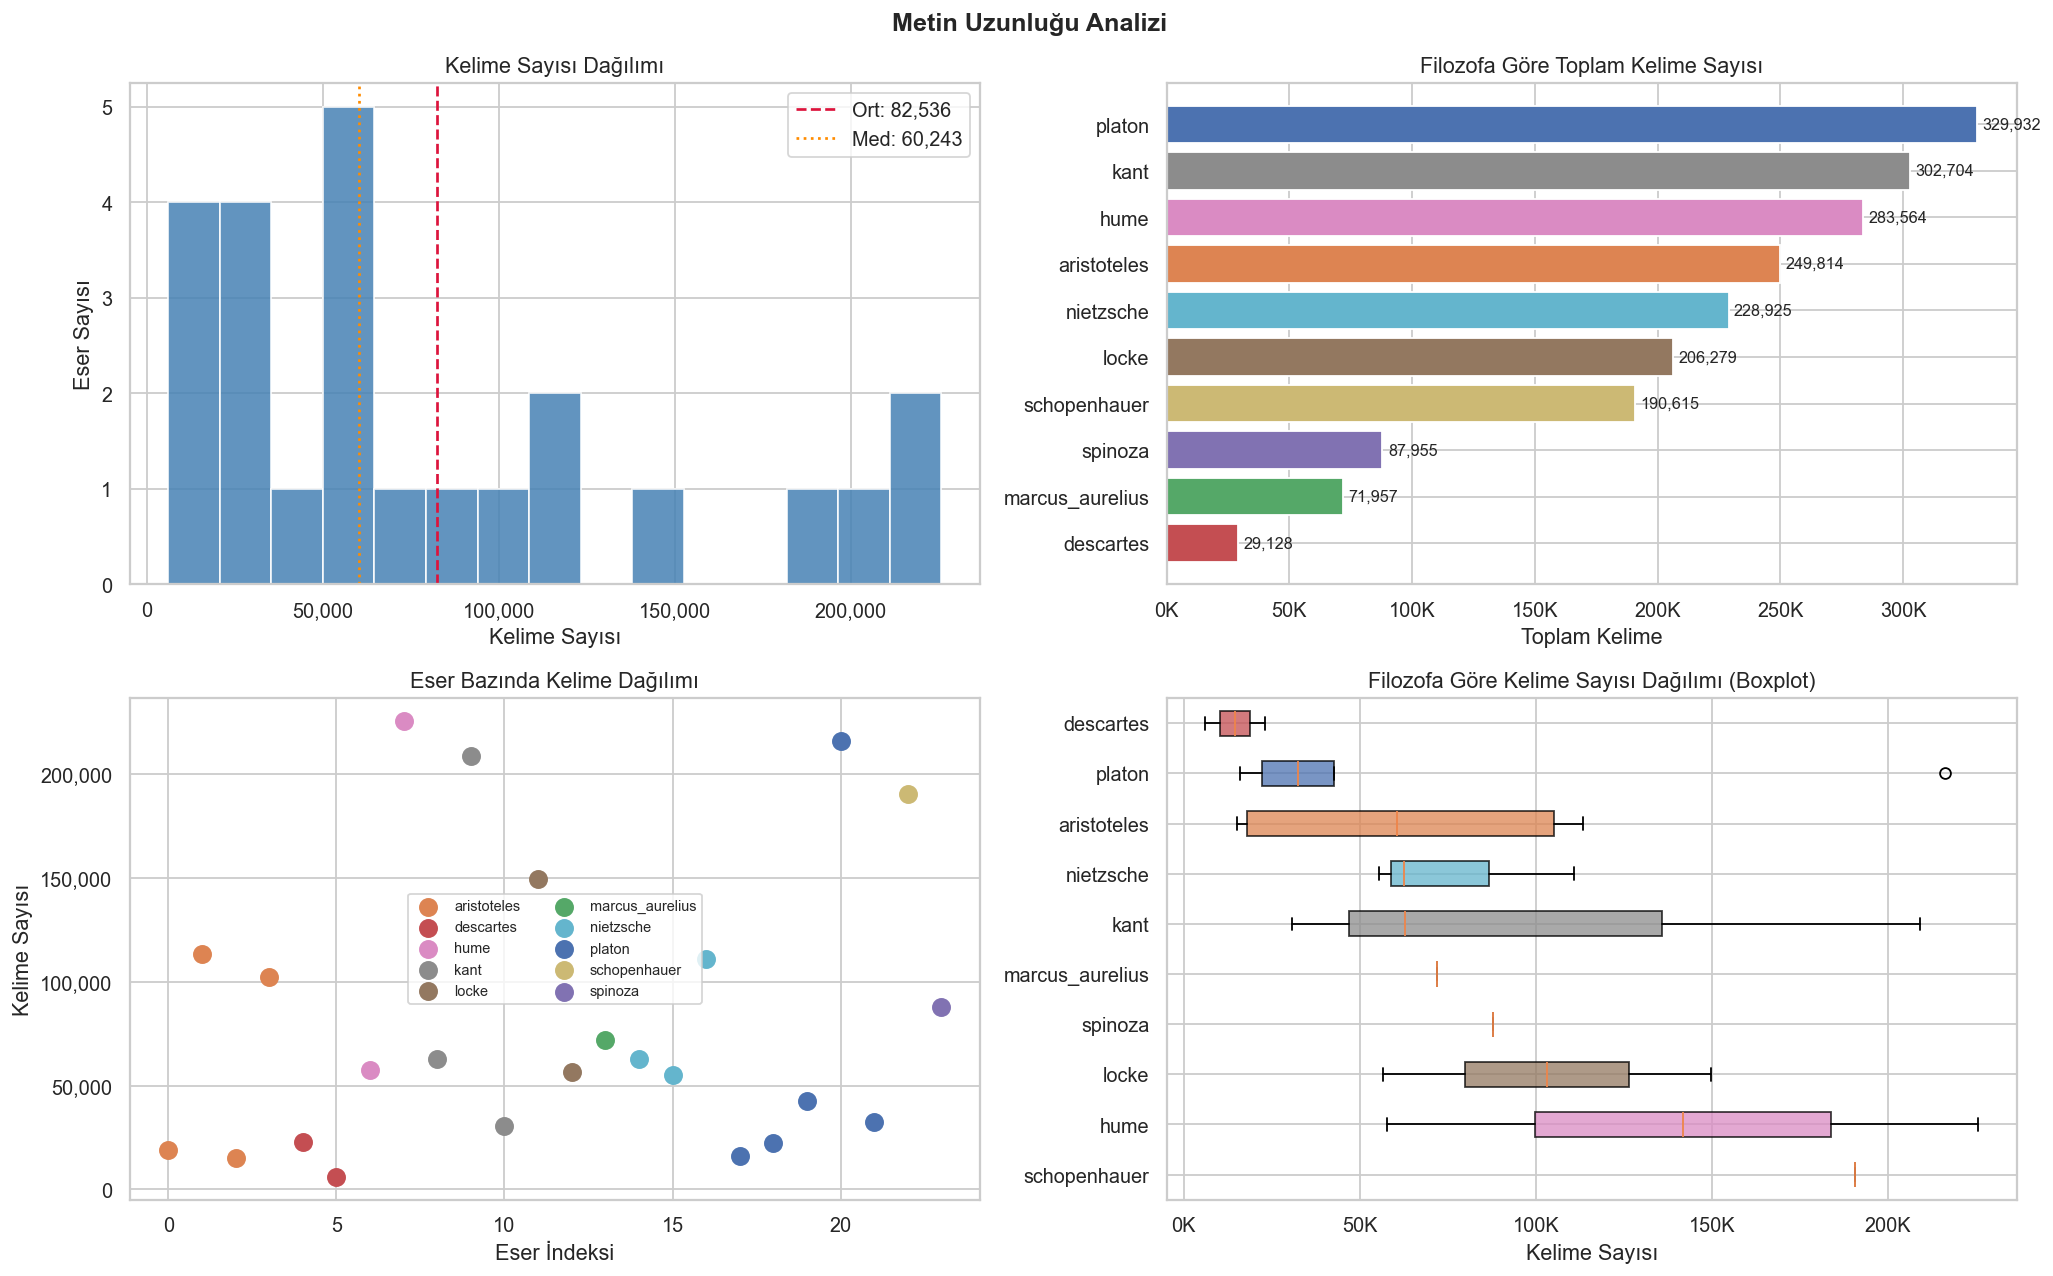

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 4a — Kelime sayısı dağılımı (histogram)
ax = axes[0, 0]
ax.hist(df['word_count'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['word_count'].mean(), color='crimson', linestyle='--', label=f"Ort: {df['word_count'].mean():,.0f}")
ax.axvline(df['word_count'].median(), color='darkorange', linestyle=':', label=f"Med: {df['word_count'].median():,.0f}")
ax.set_xlabel('Kelime Sayısı')
ax.set_ylabel('Eser Sayısı')
ax.set_title('Kelime Sayısı Dağılımı')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 4b — Filozofa göre toplam kelime sayısı
ax = axes[0, 1]
phil_words = df.groupby('philosopher')['word_count'].sum().sort_values(ascending=True)
bars = ax.barh(phil_words.index, phil_words.values,
               color=[PHIL_COLORS.get(p, '#888') for p in phil_words.index])
ax.bar_label(bars, fmt=lambda x: f'{int(x):,}', padding=3, fontsize=9)
ax.set_xlabel('Toplam Kelime')
ax.set_title('Filozofa Göre Toplam Kelime Sayısı')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# 4c — Eser bazında kelime sayısı (scatter)
ax = axes[1, 0]
for phil, group in df.groupby('philosopher'):
    ax.scatter(group.index, group['word_count'], label=phil,
               color=PHIL_COLORS.get(phil, '#888'), s=90, zorder=3)
ax.set_xlabel('Eser İndeksi')
ax.set_ylabel('Kelime Sayısı')
ax.set_title('Eser Bazında Kelime Dağılımı')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(ncol=2, fontsize=8)

# 4d — Kelime sayısı kutu grafiği (boxplot per philosopher)
ax = axes[1, 1]
philosophers_sorted = df.groupby('philosopher')['word_count'].median().sort_values(ascending=False).index
data_for_box = [df[df['philosopher'] == p]['word_count'].values for p in philosophers_sorted]
bp = ax.boxplot(data_for_box, vert=False, patch_artist=True, notch=False)
for patch, phil in zip(bp['boxes'], philosophers_sorted):
    patch.set_facecolor(PHIL_COLORS.get(phil, '#888'))
    patch.set_alpha(0.75)
ax.set_yticks(range(1, len(philosophers_sorted)+1))
ax.set_yticklabels(philosophers_sorted)
ax.set_xlabel('Kelime Sayısı')
ax.set_title('Filozofa Göre Kelime Sayısı Dağılımı (Boxplot)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.suptitle('Metin Uzunluğu Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_text_length.png', bbox_inches='tight')
plt.show()

In [7]:
print('=== Eser Bazında Detay Tablosu ===')
df[['philosopher','work','era','school','word_count','char_count']]\
  .sort_values('word_count', ascending=False)\
  .assign(word_count=lambda x: x['word_count'].map('{:,}'.format))\
  .assign(char_count=lambda x: x['char_count'].map('{:,}'.format))\
  .reset_index(drop=True)

=== Eser Bazında Detay Tablosu ===


,philosopher,work,era,school,word_count,char_count
0,hume,treatise_human_nature,modern,empiricism,"225,756","1,345,701"
1,platon,republic,ancient_greek,idealism,"216,285","1,218,976"
2,kant,critique_of_pure_reason,modern,transandantal_idealism,"209,061","1,290,827"
3,schopenhauer,world_as_will_and_idea,modern,pessimism,"190,615","1,132,165"
4,locke,essay_human_understanding,modern,empiricism,"149,762","848,413"
5,aristoteles,nicomachean_ethics,ancient_greek,realism,"113,322","648,681"
6,nietzsche,thus_spake_zarathustra,Contemporary,existentialism,"110,900","652,901"
7,aristoteles,politics,ancient_greek,realism,"102,339","584,511"
8,spinoza,ethics,modern,rationalism,"87,955","511,843"
9,marcus_aurelius,meditations,ancient_greek,stoicism,"71,957","405,045"


## 5. Kelime Hazinesi & Sözcük Analizi

In [8]:
STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOPS = {'would','could','shall','may','might','must','upon','also','one',
               'every','us','let','thus','yet','even','made','said','make',
               'therefore','though','since','whether','else','however','still',
               'without','two','three','first','second','third','much','many',
               'like','well','know','say','see','come','go','take','give','use'}
STOP_WORDS.update(EXTRA_STOPS)

def get_clean_words(text):
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [t for t in tokens if t not in STOP_WORDS]

# Filozofa göre kelime hazinesi istatistikleri
vocab_stats = []
for phil, group in df.groupby('philosopher'):
    all_text = ' '.join(group['text'].tolist())
    all_words = get_clean_words(all_text)
    total = len(all_words)
    unique = len(set(all_words))
    ttr = unique / total if total > 0 else 0
    vocab_stats.append({
        'philosopher': phil,
        'total_tokens': total,
        'unique_types': unique,
        'ttr': round(ttr, 4),
    })

vocab_df = pd.DataFrame(vocab_stats).sort_values('total_tokens', ascending=False)
print('=== Kelime Hazinesi Tablosu ===')
print(vocab_df.to_string(index=False))

=== Kelime Hazinesi Tablosu ===
    philosopher  total_tokens  unique_types    ttr
         platon        125081         11911 0.0952
           kant        124904          7799 0.0624
           hume        115677          8194 0.0708
      nietzsche        102456         15085 0.1472
    aristoteles         95798          9781 0.1021
          locke         79972          7966 0.0996
   schopenhauer         75968          9254 0.1218
        spinoza         37223          3569 0.0959
marcus_aurelius         29855          5781 0.1936
      descartes         11272          3645 0.3234


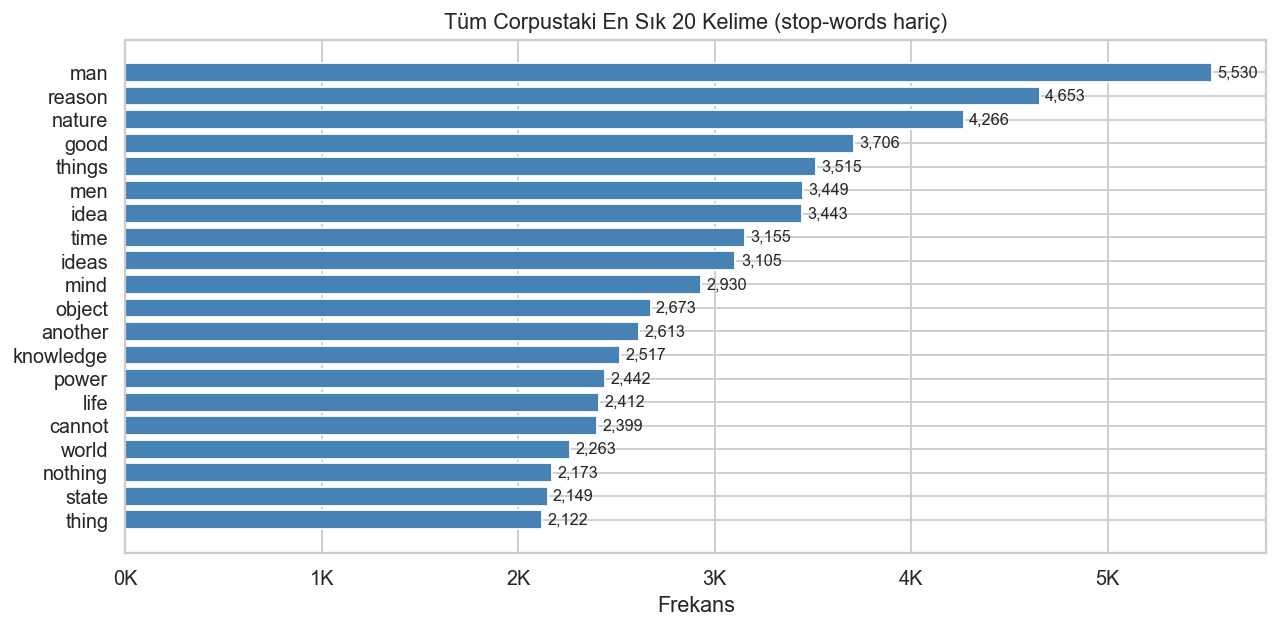

In [9]:
# En sık kullanılan 20 kelime (tüm corpus)
all_text_combined = ' '.join(df['text'].tolist())
all_clean = get_clean_words(all_text_combined)
top20_overall = Counter(all_clean).most_common(20)

fig, ax = plt.subplots(figsize=(10, 5))
words, freqs = zip(*top20_overall)
bars = ax.barh(list(reversed(words)), list(reversed(freqs)), color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{int(x):,}', padding=3, fontsize=9)
ax.set_xlabel('Frekans')
ax.set_title('Tüm Corpustaki En Sık 20 Kelime (stop-words hariç)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.tight_layout()
plt.savefig('../docs/eda_top20_words.png', bbox_inches='tight')
plt.show()

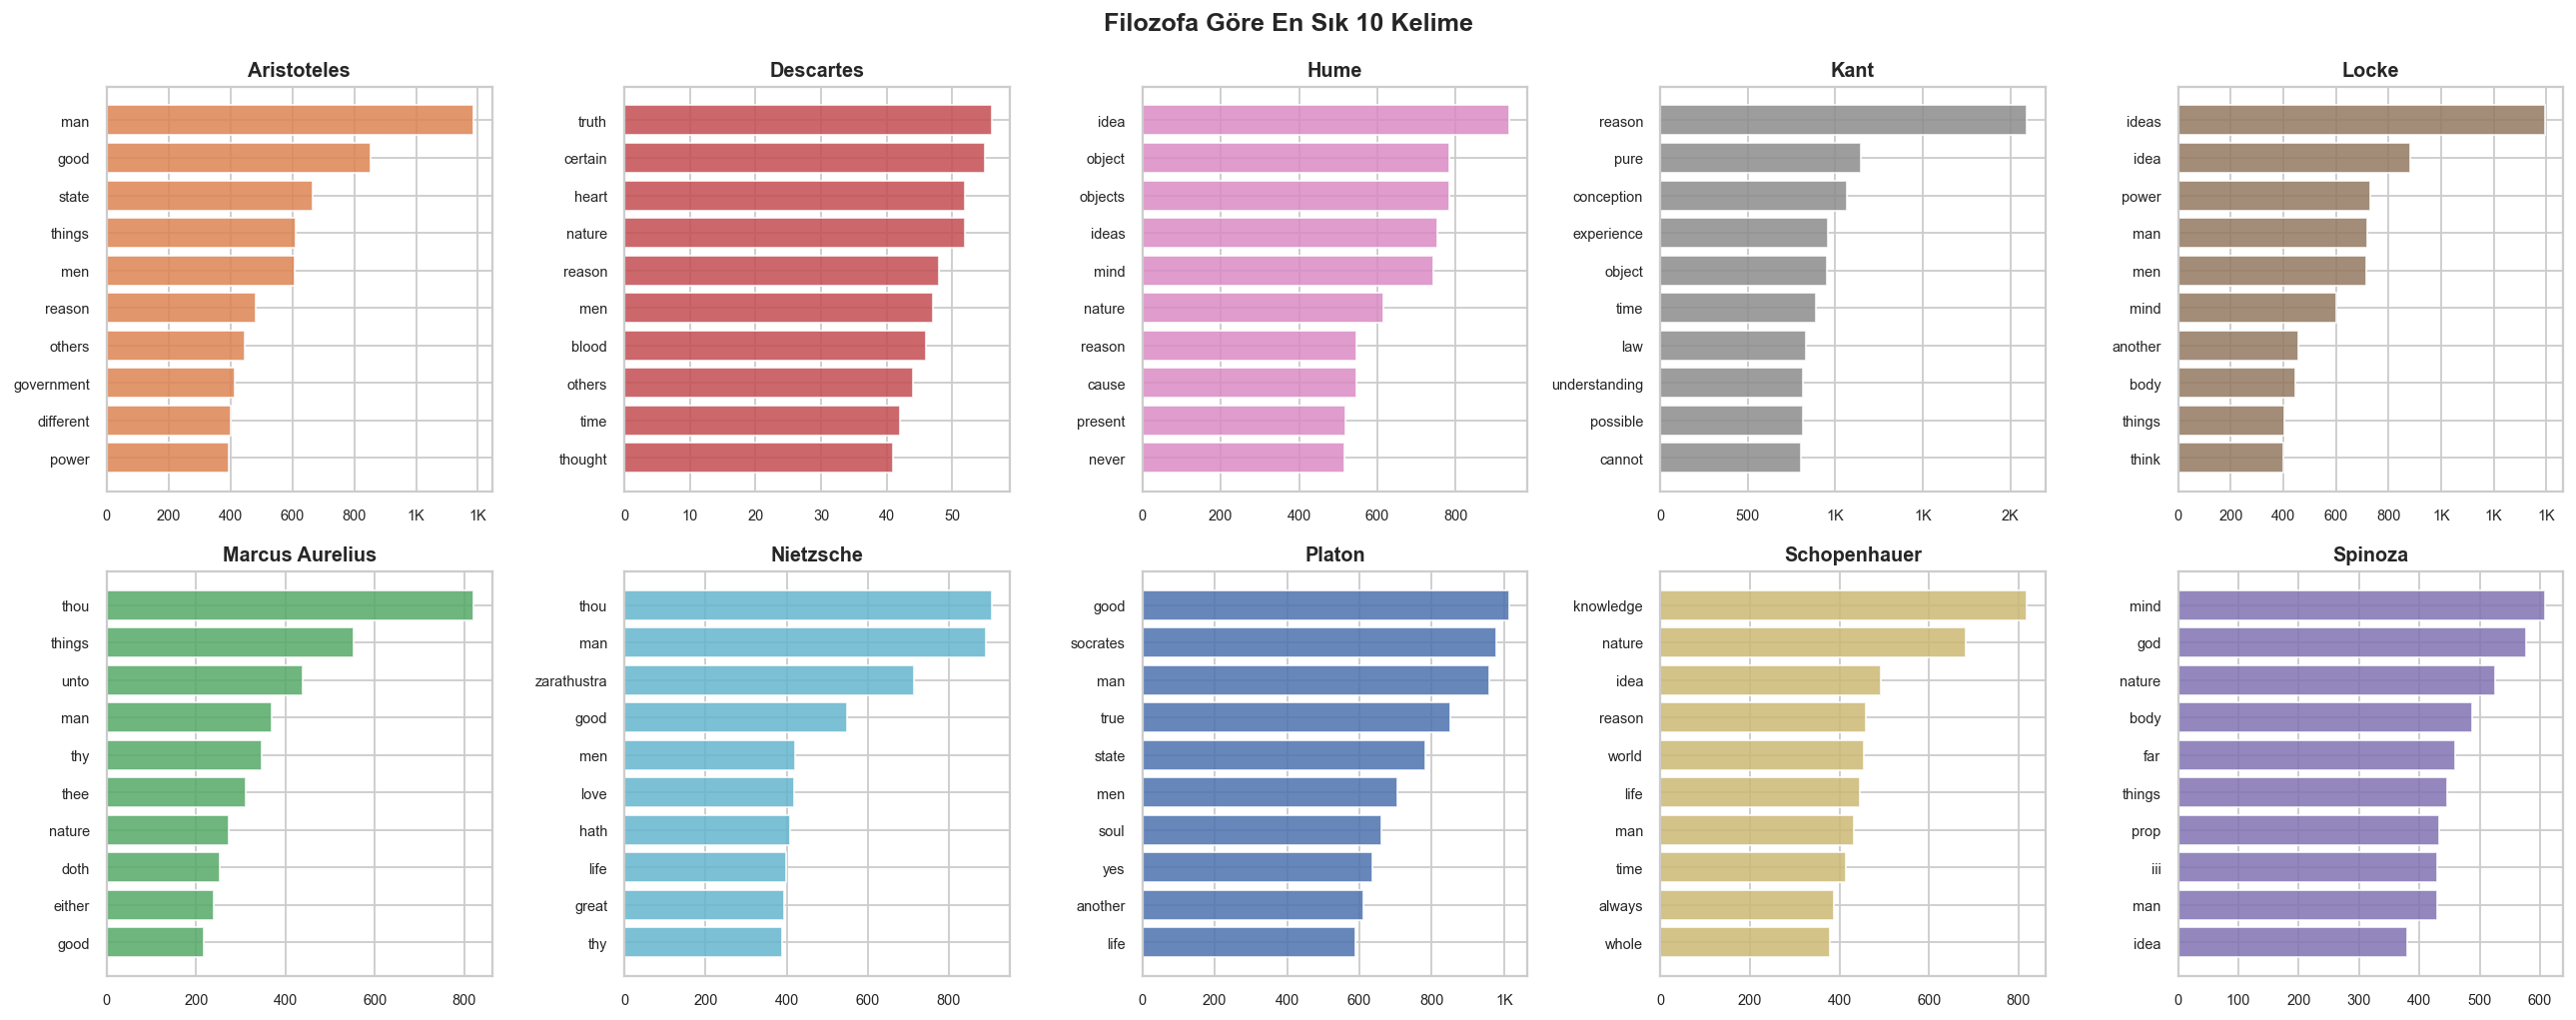

In [10]:
# Filozofa göre en sık 10 kelime (grid)
philosophers = sorted(df['philosopher'].unique())
ncols = 5
nrows = (len(philosophers) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for idx, phil in enumerate(philosophers):
    text = ' '.join(df[df['philosopher'] == phil]['text'].tolist())
    words = get_clean_words(text)
    top10 = Counter(words).most_common(10)
    w, f = zip(*top10)
    ax = axes[idx]
    ax.barh(list(reversed(w)), list(reversed(f)), color=PHIL_COLORS.get(phil, '#888'), alpha=0.85)
    ax.set_title(phil.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))

for j in range(len(philosophers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Filozofa Göre En Sık 10 Kelime', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_top10_per_philosopher.png', bbox_inches='tight')
plt.show()

## 6. Leksikal Çeşitlilik (Type-Token Ratio)

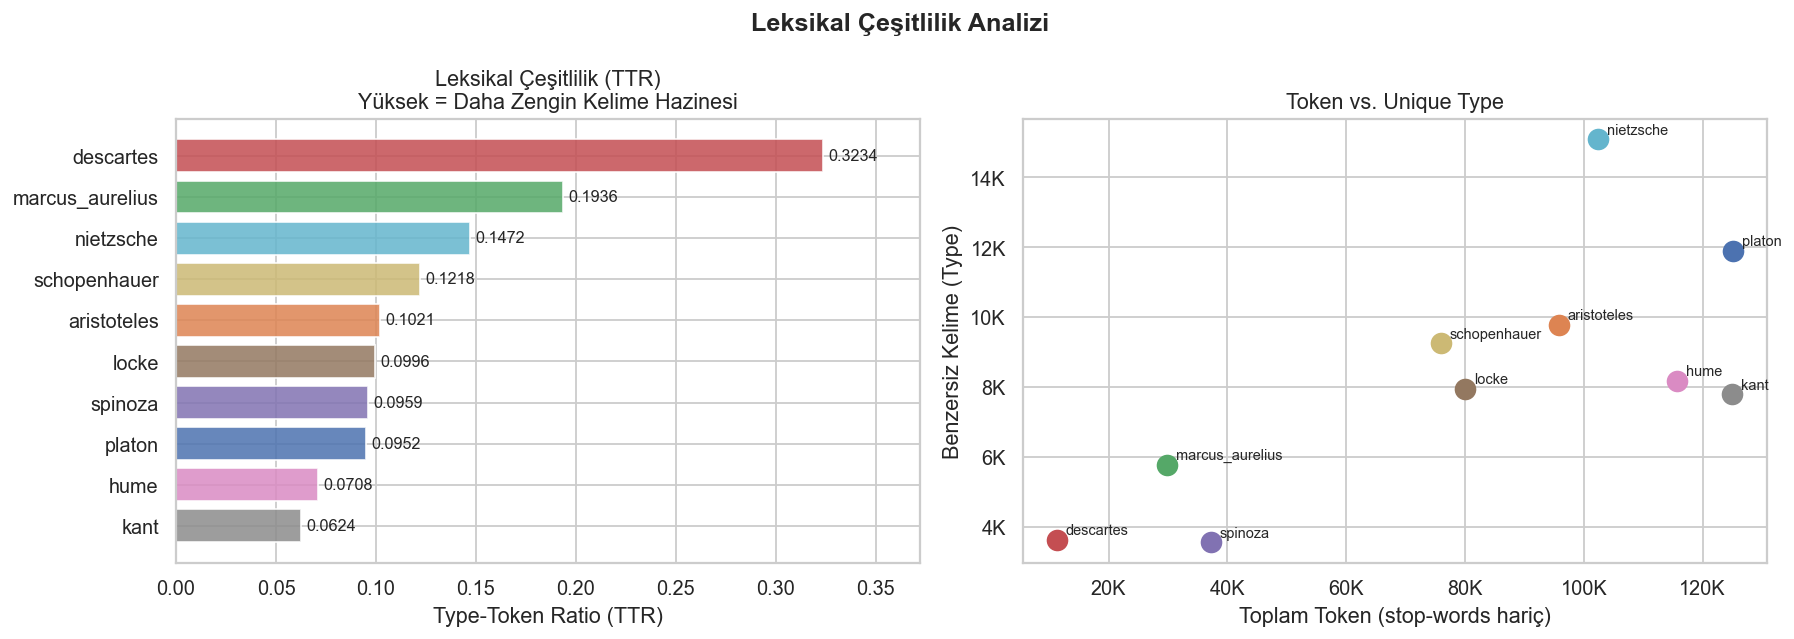

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TTR bar chart
ax = axes[0]
vdf = vocab_df.sort_values('ttr', ascending=True)
bars = ax.barh(vdf['philosopher'], vdf['ttr'],
               color=[PHIL_COLORS.get(p, '#888') for p in vdf['philosopher']], alpha=0.85)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Type-Token Ratio (TTR)')
ax.set_title('Leksikal Çeşitlilik (TTR)\nYüksek = Daha Zengin Kelime Hazinesi')
ax.set_xlim(0, vdf['ttr'].max() * 1.15)

# Unique types vs total tokens scatter
ax = axes[1]
for _, row in vocab_df.iterrows():
    ax.scatter(row['total_tokens'], row['unique_types'],
               s=120, color=PHIL_COLORS.get(row['philosopher'], '#888'),
               zorder=3, label=row['philosopher'])
    ax.annotate(row['philosopher'], (row['total_tokens'], row['unique_types']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel('Toplam Token (stop-words hariç)')
ax.set_ylabel('Benzersiz Kelime (Type)')
ax.set_title('Token vs. Unique Type')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.suptitle('Leksikal Çeşitlilik Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_lexical_diversity.png', bbox_inches='tight')
plt.show()

## 7. Cümle & Kelime Uzunluğu Analizi

In [12]:
def compute_sentence_stats(text):
    sentences = sent_tokenize(text)
    sent_lengths = [len(s.split()) for s in sentences if len(s.split()) > 2]
    word_lengths = [len(w) for w in re.findall(r'\b[a-zA-Z]+\b', text)]
    return {
        'avg_sent_len': np.mean(sent_lengths) if sent_lengths else 0,
        'median_sent_len': np.median(sent_lengths) if sent_lengths else 0,
        'avg_word_len': np.mean(word_lengths) if word_lengths else 0,
        'num_sentences': len(sent_lengths),
    }

# Filozofa göre ortalama cümle istatistikleri
sent_stats = []
for phil, group in df.groupby('philosopher'):
    combined = ' '.join(group['text'].tolist()[:3])  # ilk 3 eser yeterli
    stats = compute_sentence_stats(combined[:150_000])  # hız için kırp
    stats['philosopher'] = phil
    sent_stats.append(stats)

sent_df = pd.DataFrame(sent_stats).sort_values('avg_sent_len', ascending=False)
print('=== Cümle & Kelime Uzunluğu Özeti ===')
print(sent_df[['philosopher','avg_sent_len','median_sent_len','avg_word_len','num_sentences']]
      .round(2).to_string(index=False))

=== Cümle & Kelime Uzunluğu Özeti ===
    philosopher  avg_sent_len  median_sent_len  avg_word_len  num_sentences
      descartes         75.08             64.0          4.50            349
           kant         46.22             41.0          4.67            535
          locke         38.56             34.0          4.43            678
   schopenhauer         37.14             32.0          4.64            679
      nietzsche         33.66             24.0          4.72            715
           hume         32.07             32.0          4.71            774
marcus_aurelius         29.32             24.0          4.37            898
    aristoteles         28.28             26.0          4.44            914
         platon         26.66             22.0          4.28           1012
        spinoza         24.47             20.0          4.40           1022


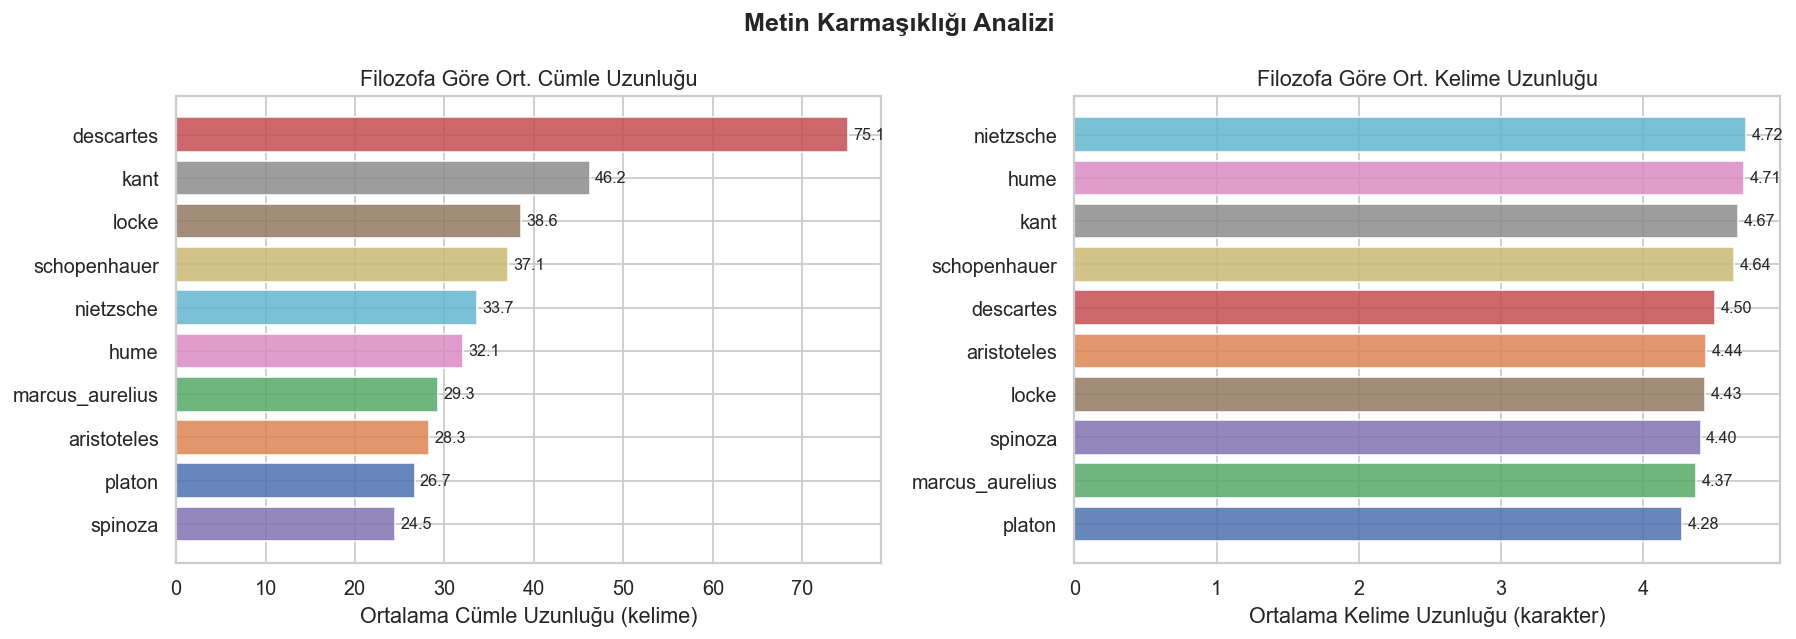

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ort. cümle uzunluğu
ax = axes[0]
sdf = sent_df.sort_values('avg_sent_len', ascending=True)
bars = ax.barh(sdf['philosopher'], sdf['avg_sent_len'],
               color=[PHIL_COLORS.get(p,'#888') for p in sdf['philosopher']], alpha=0.85)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlabel('Ortalama Cümle Uzunluğu (kelime)')
ax.set_title('Filozofa Göre Ort. Cümle Uzunluğu')

# Ort. kelime uzunluğu
ax = axes[1]
wdf = sent_df.sort_values('avg_word_len', ascending=True)
bars = ax.barh(wdf['philosopher'], wdf['avg_word_len'],
               color=[PHIL_COLORS.get(p,'#888') for p in wdf['philosopher']], alpha=0.85)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('Ortalama Kelime Uzunluğu (karakter)')
ax.set_title('Filozofa Göre Ort. Kelime Uzunluğu')

plt.suptitle('Metin Karmaşıklığı Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_complexity.png', bbox_inches='tight')
plt.show()

## 8. N-gram Analizi

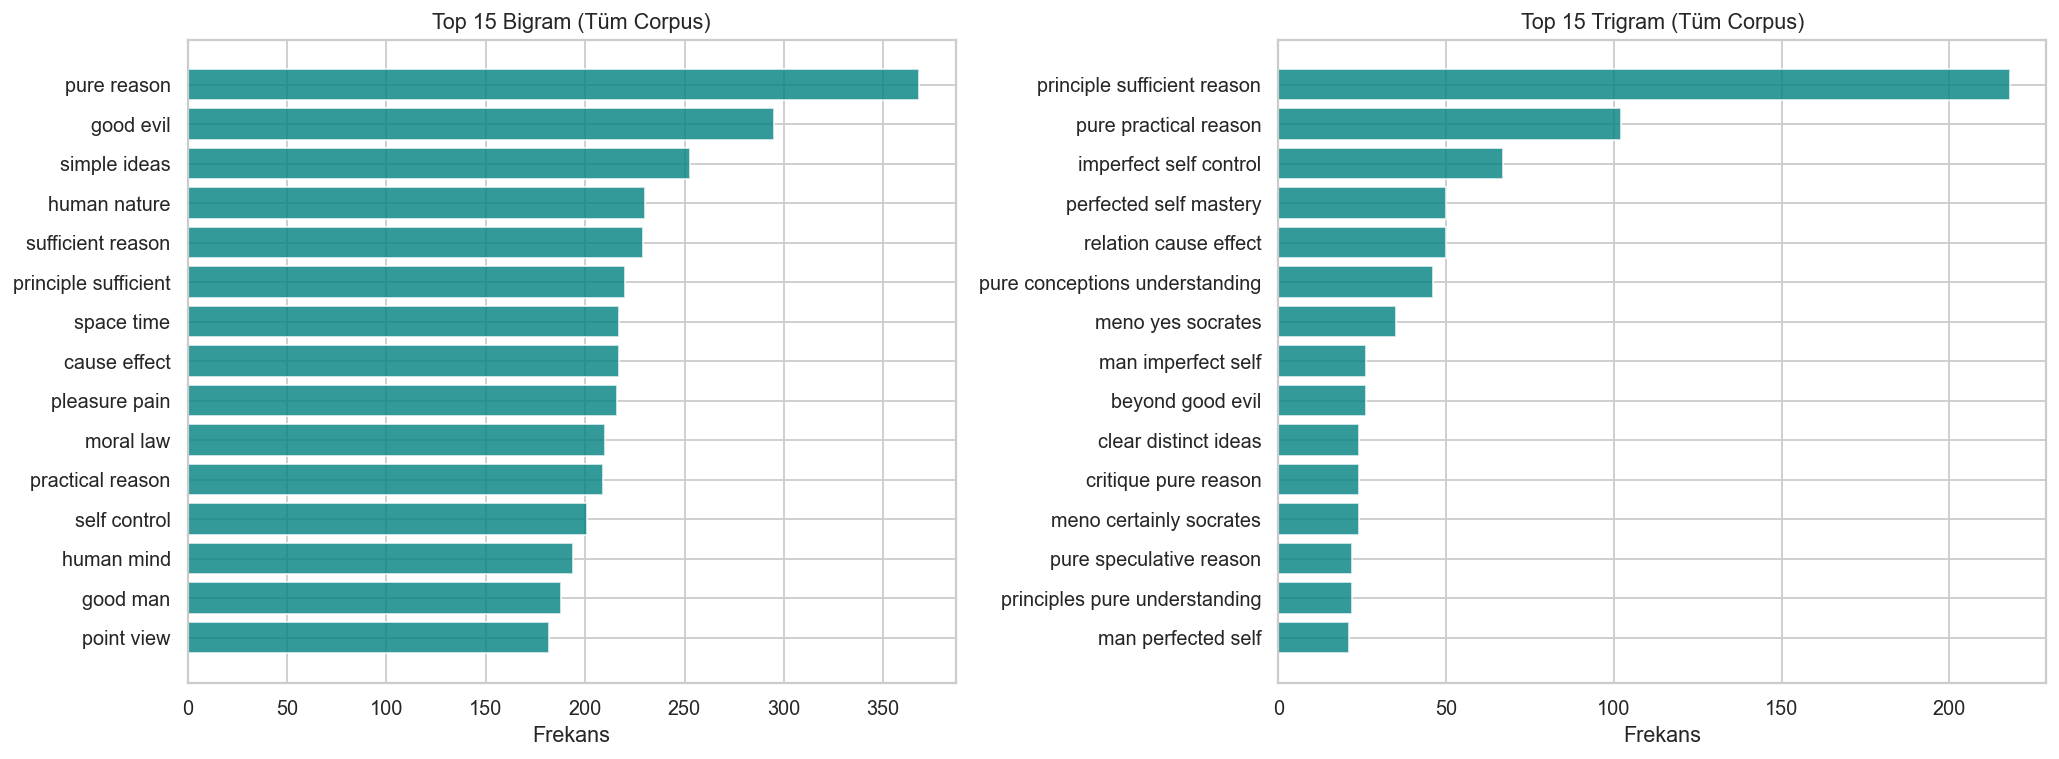

In [14]:
def get_ngrams(text, n=2, top_k=10):
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
    tokens = [t for t in tokens if t not in STOP_WORDS]
    ngrams = zip(*[tokens[i:] for i in range(n)])
    return Counter(ngrams).most_common(top_k)

# Bigram ve trigram — tüm corpus
full_text = ' '.join(df['text'].tolist())
top_bigrams  = get_ngrams(full_text, n=2, top_k=15)
top_trigrams = get_ngrams(full_text, n=3, top_k=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grams, title in [
    (axes[0], top_bigrams,  'Top 15 Bigram (Tüm Corpus)'),
    (axes[1], top_trigrams, 'Top 15 Trigram (Tüm Corpus)'),
]:
    labels = [' '.join(g) for g, _ in grams]
    counts = [c for _, c in grams]
    ax.barh(list(reversed(labels)), list(reversed(counts)), color='teal', alpha=0.8)
    ax.set_xlabel('Frekans')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../docs/eda_ngrams.png', bbox_inches='tight')
plt.show()

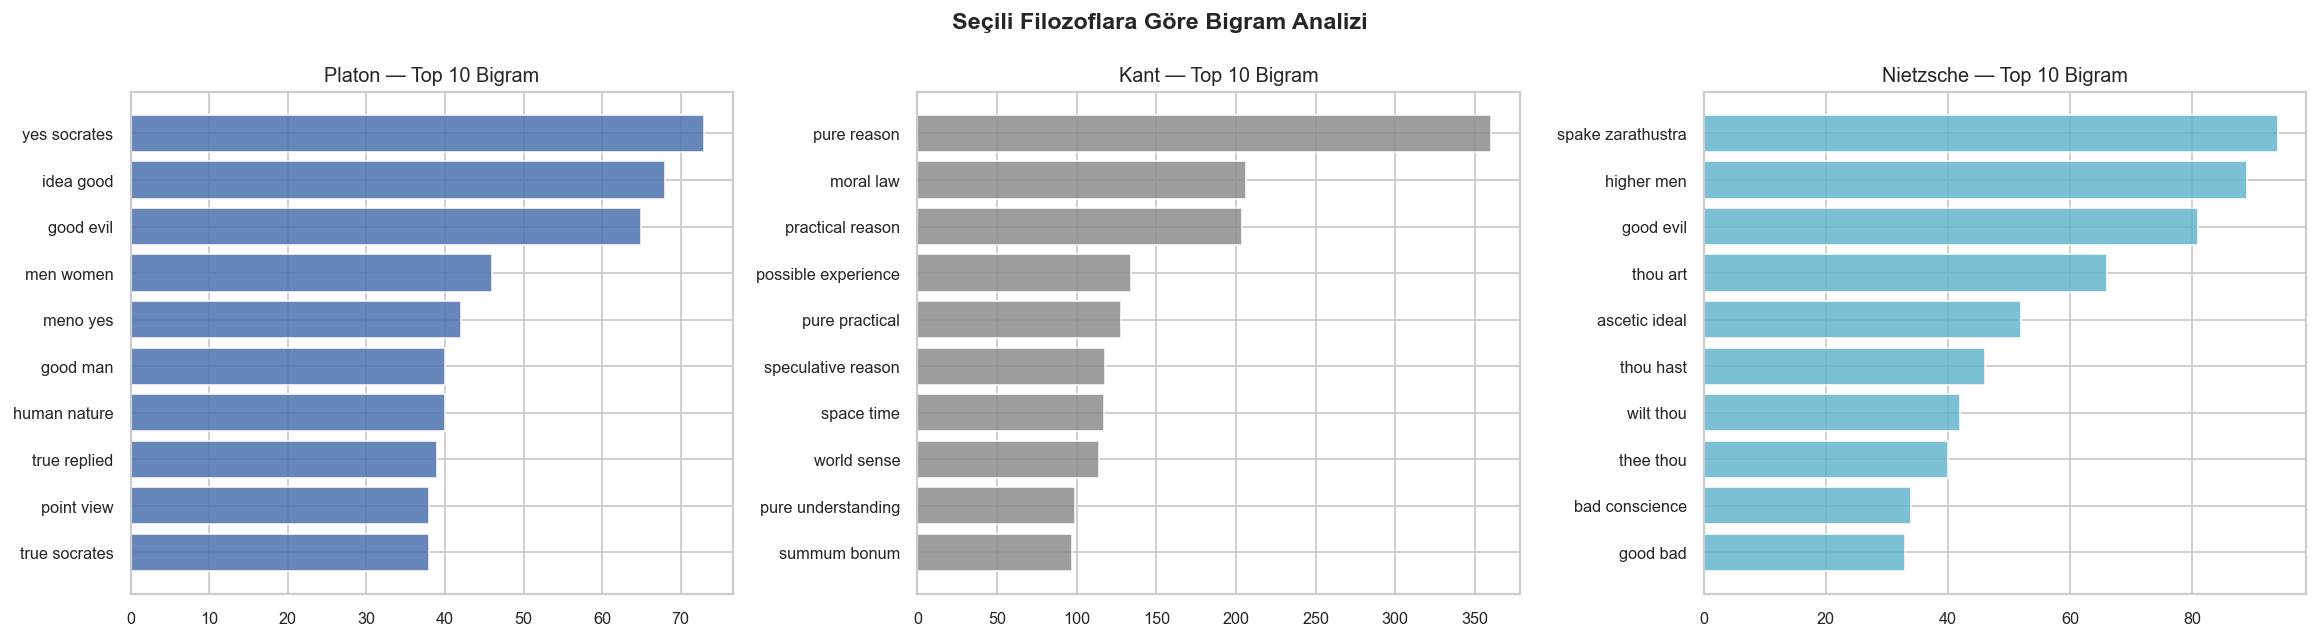

In [15]:
# Filozofa özel bigram karşılaştırması (3 örnek)
sample_phils = ['platon', 'kant', 'nietzsche']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, phil in zip(axes, sample_phils):
    text = ' '.join(df[df['philosopher'] == phil]['text'].tolist())
    top_bg = get_ngrams(text, n=2, top_k=10)
    labels = [' '.join(g) for g, _ in top_bg]
    counts = [c for _, c in top_bg]
    ax.barh(list(reversed(labels)), list(reversed(counts)),
            color=PHIL_COLORS.get(phil, '#888'), alpha=0.85)
    ax.set_title(f'{phil.title()} — Top 10 Bigram', fontsize=11)
    ax.tick_params(labelsize=9)

plt.suptitle('Seçili Filozoflara Göre Bigram Analizi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_bigrams_by_philosopher.png', bbox_inches='tight')
plt.show()

## 9. Kelime Bulutu Görselleştirmeleri

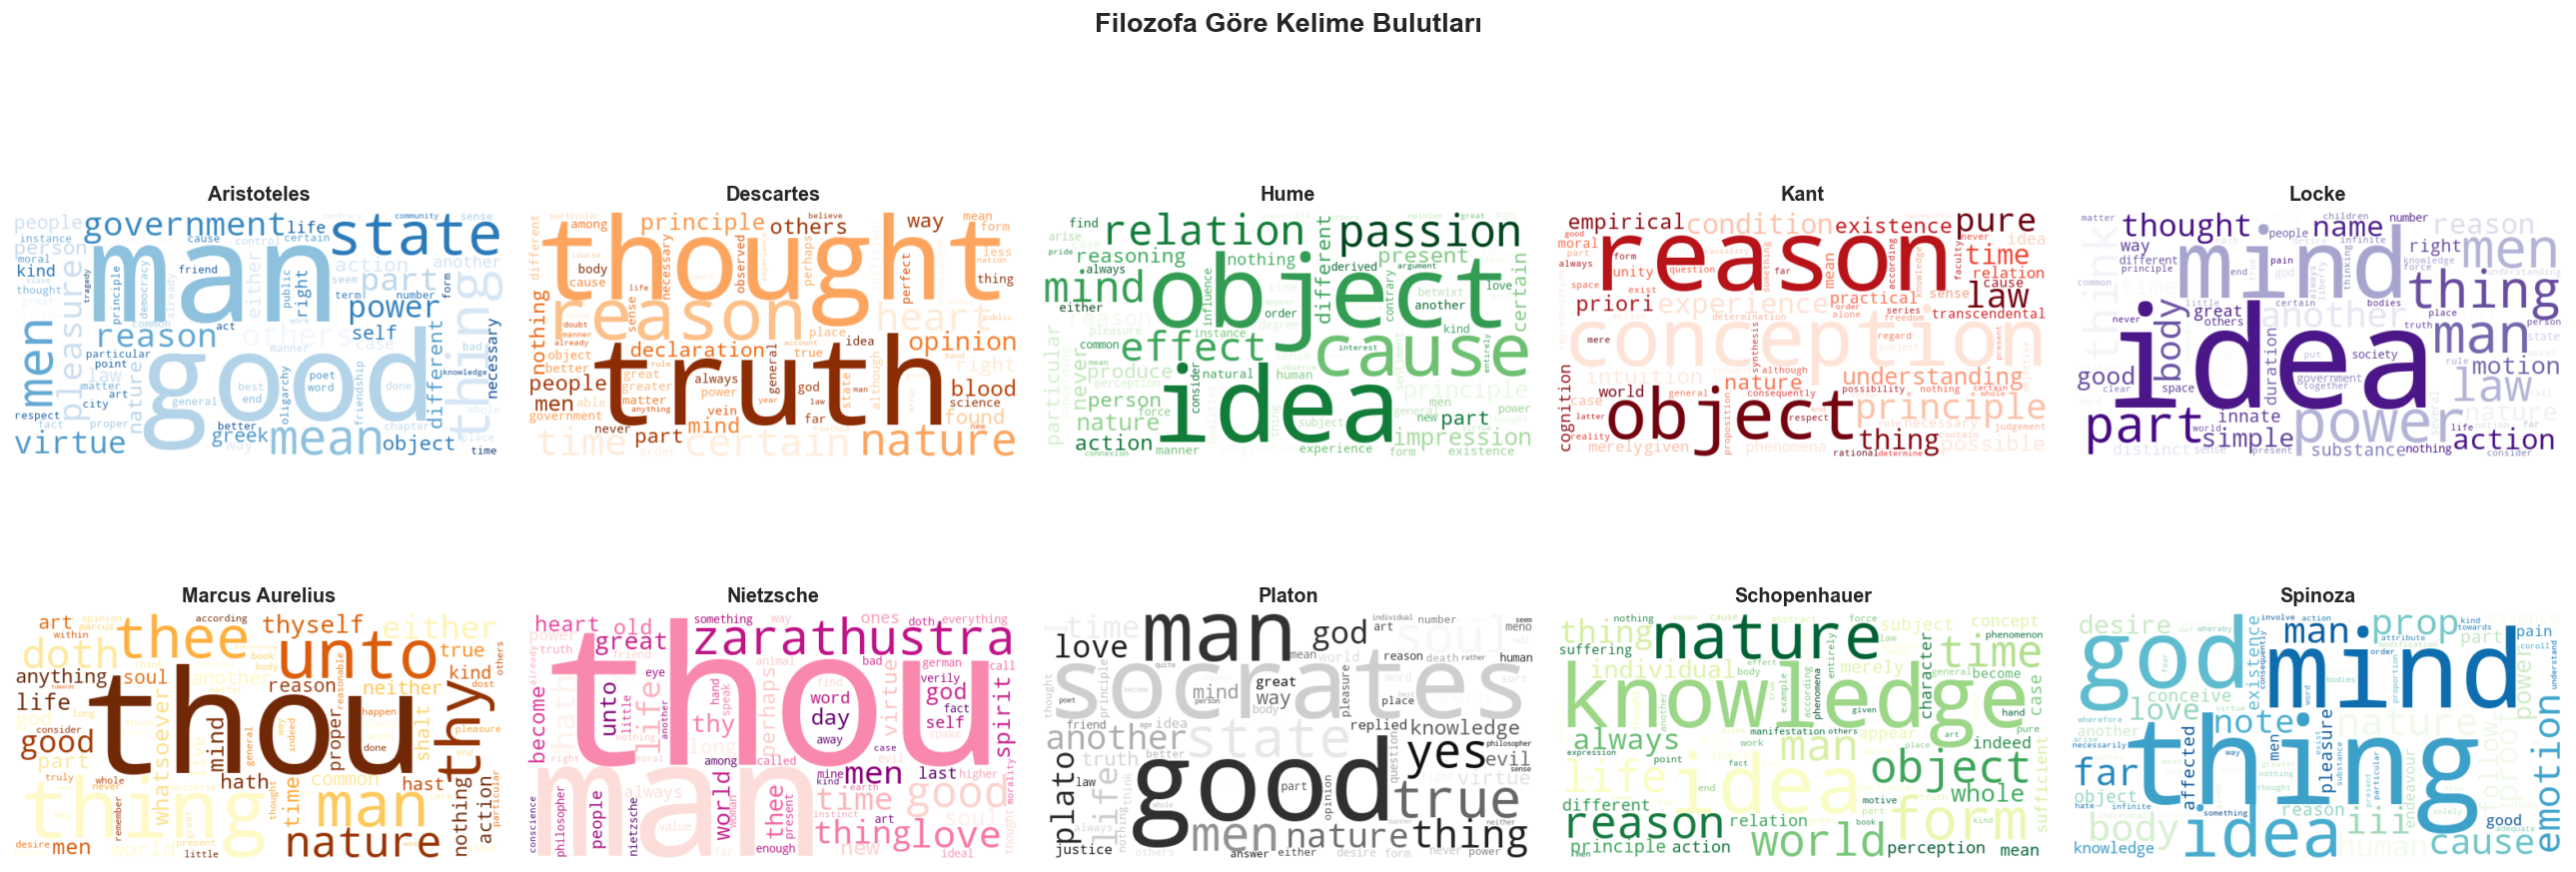

In [16]:
def make_wordcloud(text, title, color):
    clean = ' '.join(get_clean_words(text))
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap='Blues' if color == 'blue' else 'Oranges',
        max_words=80,
        collocations=False,
    ).generate(clean)
    return wc

philosophers = sorted(df['philosopher'].unique())
ncols = 5
nrows = (len(philosophers) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

cmaps = ['Blues','Oranges','Greens','Reds','Purples','YlOrBr','RdPu','Greys','YlGn','GnBu']
for idx, phil in enumerate(philosophers):
    text = ' '.join(df[df['philosopher'] == phil]['text'].tolist())
    clean = ' '.join(get_clean_words(text))
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=cmaps[idx % len(cmaps)],
        max_words=80, collocations=False,
    ).generate(clean)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(phil.replace('_', ' ').title(), fontsize=11, fontweight='bold')

for j in range(len(philosophers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Filozofa Göre Kelime Bulutları', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Chunk Analizi

In [17]:
# Chunk üretimi (512 kelime / 64 overlap)
df_chunks = chunk_texts(df, chunk_size=512, overlap=64)
print(f'Toplam chunk sayısı: {len(df_chunks):,}')
print(f'Sütunlar: {list(df_chunks.columns)}')
df_chunks.head(3)

2026-02-25 15:08:50.692 | INFO     | src.data.load_data:chunk_texts:122 - splitting: 24 works -> 4431 chunks


Toplam chunk sayısı: 4,431
Sütunlar: ['philosopher', 'work', 'era', 'school', 'text', 'chunk_idx']


,philosopher,work,era,school,text,chunk_idx
0,aristoteles,metaphysics,ancient_greek,realism,Produced by Eric Eldred ON THE ART OF POETRY B...,0
1,aristoteles,metaphysics,ancient_greek,realism,greatest Aristotelians of the nineteenth centu...,1
2,aristoteles,metaphysics,ancient_greek,realism,"separate or (2) mixed. Rhythm and tune alone, ...",2


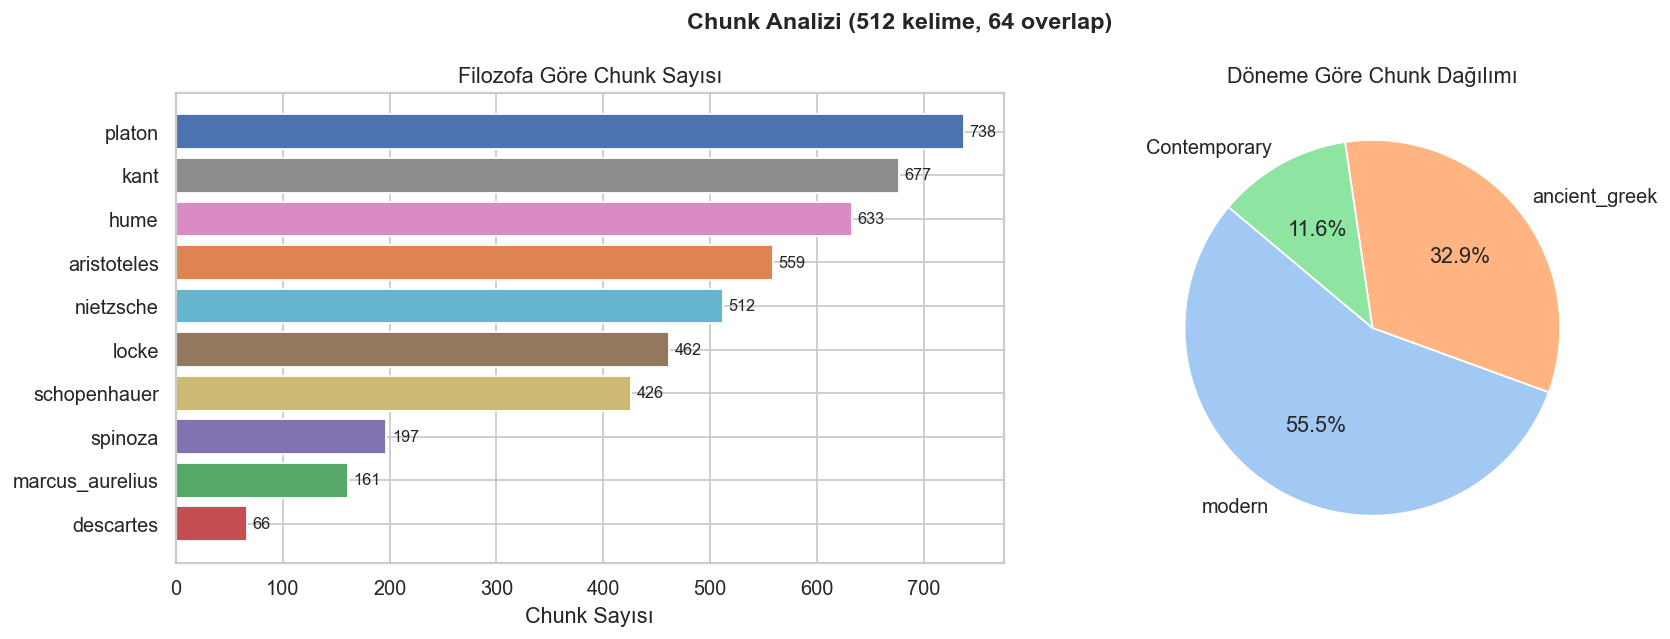


Chunk başına ortalama kelime: 511
Sınıf dengesizlik oranı (min/max): 0.089


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chunk sayısı per philosopher
ax = axes[0]
chunk_counts = df_chunks['philosopher'].value_counts().sort_values()
bars = ax.barh(chunk_counts.index, chunk_counts.values,
               color=[PHIL_COLORS.get(p,'#888') for p in chunk_counts.index])
ax.bar_label(bars, fmt=lambda x: f'{int(x):,}', padding=3, fontsize=9)
ax.set_xlabel('Chunk Sayısı')
ax.set_title('Filozofa Göre Chunk Sayısı')

# Chunk dağılımı pie (era bazında)
ax = axes[1]
era_chunk = df_chunks['era'].value_counts()
ax.pie(era_chunk.values, labels=era_chunk.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('pastel', len(era_chunk)))
ax.set_title('Döneme Göre Chunk Dağılımı')

plt.suptitle('Chunk Analizi (512 kelime, 64 overlap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_chunks.png', bbox_inches='tight')
plt.show()

print(f"\nChunk başına ortalama kelime: {df_chunks['text'].str.split().str.len().mean():.0f}")
print(f"Sınıf dengesizlik oranı (min/max): {chunk_counts.min()/chunk_counts.max():.3f}")

In [19]:
# Sınıf dağılımı — modelleme için kritik
print('=== Sınıf Dağılımı (Philosopher — Chunk) ===')
class_dist = df_chunks['philosopher'].value_counts()
total = len(df_chunks)
for phil, cnt in class_dist.items():
    pct = cnt / total * 100
    bar = '█' * int(pct / 2)
    print(f"{phil:<20} {cnt:>5,} ({pct:5.1f}%) {bar}")

=== Sınıf Dağılımı (Philosopher — Chunk) ===
platon                 738 ( 16.7%) ████████
kant                   677 ( 15.3%) ███████
hume                   633 ( 14.3%) ███████
aristoteles            559 ( 12.6%) ██████
nietzsche              512 ( 11.6%) █████
locke                  462 ( 10.4%) █████
schopenhauer           426 (  9.6%) ████
spinoza                197 (  4.4%) ██
marcus_aurelius        161 (  3.6%) █
descartes               66 (  1.5%) 


## 11. Modelleme Öncesi Değerlendirme & Özet

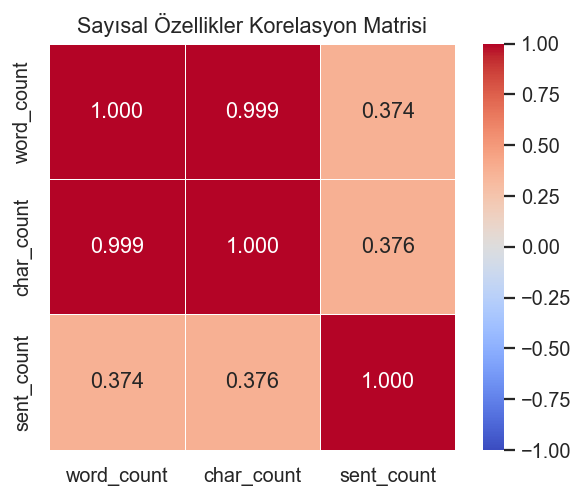

In [20]:
# Korelasyon matrisi — sayısal özellikler
df['sent_count'] = df['text'].apply(lambda t: len(sent_tokenize(t[:30000])))
numeric_cols = ['word_count', 'char_count', 'sent_count']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Sayısal Özellikler Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('../docs/eda_correlation.png', bbox_inches='tight')
plt.show()

In [21]:
print('=' * 65)
print('          PHIL-TEXT — EDA ÖZET RAPORU')
print('=' * 65)

print(f"""
CORPUS
  Eser sayısı          : {len(df)}
  Filozof sayısı       : {df['philosopher'].nunique()}
  Dönem sayısı         : {df['era'].nunique()} → {list(df['era'].unique())}
  Felsefi akım sayısı  : {df['school'].nunique()}
  Toplam kelime        : {df['word_count'].sum():,}
  Ort. kelime/eser     : {df['word_count'].mean():,.0f}
  Min kelime/eser      : {df['word_count'].min():,}  ({df.loc[df['word_count'].idxmin(), 'work']})
  Max kelime/eser      : {df['word_count'].max():,}  ({df.loc[df['word_count'].idxmax(), 'work']})

EKSİK VERİ
  Eksik değer          : {df.isnull().sum().sum()} (Temiz ✓)

CHUNK ANALİZİ (512 kelime, 64 overlap)
  Toplam chunk         : {len(df_chunks):,}
  Sınıf dengesizliği   : {chunk_counts.min()/chunk_counts.max():.3f}  (1.0 = tam dengeli)
  En az chunk          : {chunk_counts.idxmin()} ({chunk_counts.min():,})
  En çok chunk         : {chunk_counts.idxmax()} ({chunk_counts.max():,})

MODEL TASARIM ÖNERİLERİ
  ✓ Sınıf sayısı (10) makul — çok sınıflı sınıflandırma uygulanabilir
  ⚠ Sınıf dengesizliği var → weighted loss / oversampling düşün
  ✓ Yeterli metin → TF-IDF + SVM ve BERT fine-tuning uygulanabilir
  ✓ Chunk tabanlı veri ML pipeline için hazır
  ⚠ Dönem etiketi dağılımı dengesiz → modern döneme yüklü
""")
print('=' * 65)

          PHIL-TEXT — EDA ÖZET RAPORU

CORPUS
  Eser sayısı          : 24
  Filozof sayısı       : 10
  Dönem sayısı         : 3 → ['ancient_greek', 'modern', 'Contemporary']
  Felsefi akım sayısı  : 8
  Toplam kelime        : 1,980,873
  Ort. kelime/eser     : 82,536
  Min kelime/eser      : 6,089  (meditations)
  Max kelime/eser      : 225,756  (treatise_human_nature)

EKSİK VERİ
  Eksik değer          : 0 (Temiz ✓)

CHUNK ANALİZİ (512 kelime, 64 overlap)
  Toplam chunk         : 4,431
  Sınıf dengesizliği   : 0.089  (1.0 = tam dengeli)
  En az chunk          : descartes (66)
  En çok chunk         : platon (738)

MODEL TASARIM ÖNERİLERİ
  ✓ Sınıf sayısı (10) makul — çok sınıflı sınıflandırma uygulanabilir
  ⚠ Sınıf dengesizliği var → weighted loss / oversampling düşün
  ✓ Yeterli metin → TF-IDF + SVM ve BERT fine-tuning uygulanabilir
  ✓ Chunk tabanlı veri ML pipeline için hazır
  ⚠ Dönem etiketi dağılımı dengesiz → modern döneme yüklü



In [22]:
# İşlenmiş corpus kaydet
import os
os.makedirs('../data/processed', exist_ok=True)
df.drop(columns=['text']).to_csv('../data/processed/corpus_meta.csv', index=False)
df_chunks.to_parquet('../data/processed/corpus_chunks.parquet', index=False)
print('✓ Metadata → data/processed/corpus_meta.csv')
print('✓ Chunks   → data/processed/corpus_chunks.parquet')

✓ Metadata → data/processed/corpus_meta.csv
✓ Chunks   → data/processed/corpus_chunks.parquet
